# Zalando Network Planning — Warehouse Inbound Forecast

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.1f}".format)

## 1. Load Data

In [106]:
hist = pd.read_csv(
    "data_input/202402_Data - Case Study - Analyst Network Planning_vShared - input_1_histrocial.csv",
    parse_dates=["date_order", "date_wh_receive"]
)

fc = pd.read_csv(
    "data_input/202402_Data - Case Study - Analyst Network Planning_vShared - input_2_sales_fc.csv",
    parse_dates=["date_order"]
)

print("Historical data:", hist.shape)
display(hist.head())

print("\nSales forecast:", fc.shape)
display(fc.head())

Historical data: (1763, 6)


,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items
0,2022-01-01,6,2022-01-01,6,52,18338
1,2022-01-01,6,2022-01-02,7,52,408
2,2022-01-01,6,2022-01-03,1,1,2551
3,2022-01-01,6,2022-01-04,2,1,11965
4,2022-01-01,6,2022-01-05,3,1,180



Sales forecast: (30, 3)


,date_order,day_of_week_order,Forecated_items
0,2022-06-01,3,80882
1,2022-06-02,4,58562
2,2022-06-03,5,55809
3,2022-06-04,6,48880
4,2022-06-05,7,49208


## 2. Data Quality Checks

### Checking Historical Data

In [107]:
### input_1: Shape and dtypes
print("=== input_1: Historical Data ===")
print(f"Shape: {hist.shape}")
print()
print(hist.dtypes)

=== input_1: Historical Data ===
Shape: (1763, 6)

date_order                datetime64[us]
day_of_week_order                  int64
date_wh_receive           datetime64[us]
day_of_week_wh_receive             int64
CW                                 int64
items                              int64
dtype: object


All data types are loaded in correct format.

In [108]:
### input_1: Missing values
print("=== input_1: Missing Values ===")
print(hist.isnull().sum())

=== input_1: Missing Values ===
date_order                0
day_of_week_order         0
date_wh_receive           0
day_of_week_wh_receive    0
CW                        0
items                     0
dtype: int64


We don't have any nulls in the dataset.

In [109]:
### input_1: Date range
print("=== input_1: Date Range ===")
print(f"date_order:      {hist['date_order'].min().date()} → {hist['date_order'].max().date()}")
print(f"date_wh_receive: {hist['date_wh_receive'].min().date()} → {hist['date_wh_receive'].max().date()}")
print(f"Unique order dates: {hist['date_order'].nunique()}")

=== input_1: Date Range ===
date_order:      2022-01-01 → 2022-05-31
date_wh_receive: 2022-01-01 → 2022-06-11
Unique order dates: 151


Order Dates range from Jan'22 till end of May'22. However, there is a *Spillover from May orders* into June receiving, which needs to be accounted for in June forecast.

In [110]:
### input_1: Negative or zero item counts
neg_hist = hist[hist["items"] <= 0]
print(f"=== input_1: Negative or Zero Items ===")
print(f"Rows with items <= 0: {len(neg_hist)}")
if len(neg_hist) > 0:
    display(neg_hist)

=== input_1: Negative or Zero Items ===
Rows with items <= 0: 0


We don't have any 0 or negative values in 'items' data.

In [111]:
### input_1: Duplicate rows
dupes_hist = hist.duplicated().sum()
print(f"=== input_1: Duplicate Rows ===")
print(f"Duplicate rows: {dupes_hist}")

=== input_1: Duplicate Rows ===
Duplicate rows: 0


No entire duplicate records found.

### Historicals Outlier Detection

In [112]:
### input_1: Outlier check on items (IQR method)
Q1 = hist["items"].quantile(0.25)
Q3 = hist["items"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers_hist = hist[hist["items"] > upper_bound].sort_values("items", ascending=False)
print(f"=== input_1: Outliers in Items (IQR method) ===")
print(f"Q1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f} | Upper bound: {upper_bound:,.0f}")
print(f"\nRows exceeding upper bound: {len(outliers_hist)}")
if len(outliers_hist) > 0:
    display(outliers_hist)

=== input_1: Outliers in Items (IQR method) ===
Q1: 19 | Q3: 5,423 | IQR: 5,404 | Upper bound: 13,529

Rows exceeding upper bound: 326


,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items
1731,2022-05-29,7,2022-05-29,7,21,27533000
1498,2022-05-08,7,2022-05-10,2,19,74843
277,2022-01-23,7,2022-01-25,2,4,66254
289,2022-01-24,1,2022-01-26,3,4,61991
300,2022-01-25,2,2022-01-27,4,4,60645
...,...,...,...,...,...,...
606,2022-02-20,7,2022-02-21,1,8,14287
1326,2022-04-24,7,2022-04-25,1,17,14277
1543,2022-05-12,4,2022-05-13,5,19,13942
1227,2022-04-16,6,2022-04-16,6,15,13732


**Limitation of IQR method here:**

The IQR method flags 326 rows (~18.5% of data) as outliers, which is far too many to be genuine anomalies. The issue is that `items` is inherently right-skewed by design:
- **Q1 = 19** — driven down by the many small trickle amounts at long lags (e.g. 3 items arriving 15 days after order)
- **Q3 = 5,423** — where the bulk of volume sits
- The resulting upper bound of 13,529 incorrectly flags legitimate high-volume records (e.g. same-day receipts of 50,000+ items)

IQR works well for symmetric distributions. Here, the skew is structural — a few rows carry large volumes at short lags, while many rows carry tiny volumes at long lags. A **magnitude gap check** is more appropriate: it looks for a disproportionate jump between the largest value and the rest, which is the actual signature of a data entry error.

In [113]:
### input_1: Outlier check on items (magnitude gap check)
sorted_items = hist["items"].sort_values(ascending=False).reset_index(drop=True)
gap_ratio = sorted_items / sorted_items.shift(-1)

print("=== input_1: Top 10 items values with gap ratio to next ===")
top10 = pd.DataFrame({
    "items": sorted_items[:10],
    "gap_ratio_to_next": gap_ratio[:10].round(1)
})
display(top10)

# Flag rows where gap ratio exceeds 10x
threshold = 10
anomalies = hist[hist["items"] >= sorted_items[gap_ratio[gap_ratio > threshold].index[0]]] \
    if (gap_ratio > threshold).any() else pd.DataFrame()

print(f"\nRows with a >10x gap to the next highest value: {len(anomalies)}")
if len(anomalies) > 0:
    display(anomalies)

=== input_1: Top 10 items values with gap ratio to next ===


,items,gap_ratio_to_next
0,27533000,367.9
1,74843,1.1
2,66254,1.1
3,61991,1.0
4,60645,1.1
5,54253,1.1
6,50788,1.0
7,50287,1.0
8,50091,1.1
9,47516,1.1



Rows with a >10x gap to the next highest value: 1


,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items
1731,2022-05-29,7,2022-05-29,7,21,27533000


There is exactly one genuine anomaly. Everything else is legitimate high-volume data.

The May 29 record is a data entry error — the 367.9x gap is not a business pattern, it's a magnitude mistake. A realistic same-day receipt for a large retailer might be 50,000–75,000 items, which is exactly what the surrounding rows show. 27,533,000 is physically implausible.

**Outlier Handling: Impute Median**  
We want to preserve the realistic shape of May 29's lag distribution — specifically that lag=0 carries the largest share, consistent with every other order date. Imputing a plausible value restores that shape.

The most contextually appropriate choice is the median lag=0 items value for Sunday orders (day_of_week = 7) from the rest of the historical data. This accounts for:

- Same-day receipt behaviour specifically (lag=0)
- Day-of-week pattern (May 29 is a Sunday)


In [114]:
### input_1: Impute May 29 anomaly with median lag=0 Sunday value
hist["lag"] = (hist["date_wh_receive"] - hist["date_order"]).dt.days

sunday_lag0_median = hist[
    (hist["day_of_week_order"] == 7) &
    (hist["lag"] == 0) &
    (hist["items"] < 27533000)  # exclude the anomaly itself
]["items"].median()

print(f"Median lag=0 items for Sunday orders: {sunday_lag0_median:,.0f}")

# Apply imputation
hist.loc[1731, "items"] = sunday_lag0_median
print(f"\nImputed row 1731:")
display(hist.loc[[1731]])

Median lag=0 items for Sunday orders: 32,161

Imputed row 1731:


,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items,lag
1731,2022-05-29,7,2022-05-29,7,21,32161,0


In [115]:
### Total items per order date
total_per_order = hist.groupby("date_order")["items"].sum()
total_per_order.head()

date_order
2022-01-01    33614
2022-01-02    52529
2022-01-03    90112
2022-01-04    83831
2022-01-05    66818
Name: items, dtype: int64

In [116]:
# Calculate share sums per order to whs receiving date
share_sums = (
    hist.groupby(["date_order", "date_wh_receive"])["items"].sum()
    .div(total_per_order, level="date_order")
    
)
share_sums.head()

date_order  date_wh_receive
2022-01-01  2022-01-01        0.5
            2022-01-02        0.0
            2022-01-03        0.1
            2022-01-04        0.4
            2022-01-05        0.0
Name: items, dtype: float64

In [117]:
# Aggregate share sums by order date to check total shares sum to 1
share_sums = share_sums.groupby("date_order").sum()
share_sums.head()

date_order
2022-01-01   1.0
2022-01-02   1.0
2022-01-03   1.0
2022-01-04   1.0
2022-01-05   1.0
Name: items, dtype: float64

In [118]:
print("=== input_1: Item Share Sum per Order Date ===")
print(share_sums.describe().to_frame("share_sum"))
incomplete = share_sums[share_sums < 0.99]
print(f"\nOrder dates with share sum < 99%: {len(incomplete)}")
if len(incomplete) > 0:
    display(incomplete)

=== input_1: Item Share Sum per Order Date ===
       share_sum
count      151.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0

Order dates with share sum < 99%: 0


Every single order date has a perfect share sum of 1.0 — no missing receipts, no data gaps.

### Data Quality Summary — input_1 (Historical Data)

| Check | Result |
|---|---|
| Shape | 1,763 rows × 6 columns |
| Unique order dates | 151 (Jan 1 – May 31, 2022) |
| Missing values | None |
| Duplicate rows | None |
| Negative / zero items | None |
| Date range | Orders: Jan–May 2022; WH receipts extend to Jun 11, 2022 |
| Share sums per order date | All exactly 1.0 — no data gaps or losses |
| Data types | Dates as `datetime64`, numeric columns as `int64` |
| Outliers | 1 anomaly detected on May 29 (items = 27,533,000; 368x the next highest value). Identified as a data entry error via magnitude gap check. Imputed with the median lag=0 Sunday value (32,161) to preserve the realistic shape of the lag distribution. |

**Overall:** input_1 is clean and complete after outlier treatment. Late-May orders spill into early June warehouse receipts and will need to be accounted for in the forecast.

### Checking Sales Forecast Data

In [119]:
fc.head()

,date_order,day_of_week_order,Forecated_items
0,2022-06-01,3,80882
1,2022-06-02,4,58562
2,2022-06-03,5,55809
3,2022-06-04,6,48880
4,2022-06-05,7,49208


In [120]:
### input_2: Shape, dtypes, missing values
print("=== input_2: Sales Forecast ===")
print(f"Shape: {fc.shape}")
print()
print(fc.dtypes)
print()
print("Missing values:")
print(fc.isnull().sum())

=== input_2: Sales Forecast ===
Shape: (30, 3)

date_order           datetime64[us]
day_of_week_order             int64
Forecated_items               int64
dtype: object

Missing values:
date_order           0
day_of_week_order    0
Forecated_items      0
dtype: int64


Data covers 30 days, no null values.

In [121]:
### input_2: Date range and gaps
print("=== input_2: Date Range ===")
print(f"Range: {fc['date_order'].min().date()} → {fc['date_order'].max().date()}")
print(f"Unique dates: {fc['date_order'].nunique()} (expected 30 for June)")

expected_dates = pd.date_range("2022-06-01", "2022-06-30")
missing_dates = expected_dates.difference(fc["date_order"])
print(f"Missing dates: {list(missing_dates.date) if len(missing_dates) > 0 else 'None'}")

=== input_2: Date Range ===
Range: 2022-06-01 → 2022-06-30
Unique dates: 30 (expected 30 for June)
Missing dates: None


Date range covers 30 days as expected for June.

In [122]:
### input_2: Negative or zero forecasted items
neg_fc = fc[fc["Forecated_items"] <= 0]
print(f"=== input_2: Negative or Zero Forecasted Items ===")
print(f"Rows with Forecated_items <= 0: {len(neg_fc)}")
if len(neg_fc) > 0:
    display(neg_fc)

=== input_2: Negative or Zero Forecasted Items ===
Rows with Forecated_items <= 0: 0


No negative or 0 sales fcst dates.

In [123]:
### input_2: Outlier check on forecasted items (IQR method)
Q1_fc = fc["Forecated_items"].quantile(0.25)
Q3_fc = fc["Forecated_items"].quantile(0.75)
IQR_fc = Q3_fc - Q1_fc
upper_bound_fc = Q3_fc + 1.5 * IQR_fc

outliers_fc = fc[fc["Forecated_items"] > upper_bound_fc].sort_values("Forecated_items", ascending=False)
print(f"=== input_2: Outliers in Forecated_items (IQR method) ===")
print(f"Q1: {Q1_fc:,.0f} | Q3: {Q3_fc:,.0f} | IQR: {IQR_fc:,.0f} | Upper bound: {upper_bound_fc:,.0f}")
print(f"\nRows exceeding upper bound: {len(outliers_fc)}")
if len(outliers_fc) > 0:
    display(outliers_fc)

=== input_2: Outliers in Forecated_items (IQR method) ===
Q1: 63,920 | Q3: 95,487 | IQR: 31,567 | Upper bound: 142,837

Rows exceeding upper bound: 1


,date_order,day_of_week_order,Forecated_items
27,2022-06-28,2,183785


We have one outlier in the forecast on 28th June, having items forecast as 183785, which is greater than upper bound value of 142,837.

183,785 is ~1.3x the IQR upper bound (142,837) — not comparable to the 368x gap we saw in input_1. There's no evidence of a data entry error. The gap ratio to the next highest value would be small.

In [124]:
### input_2: Day-of-week distribution
print("=== input_2: Day-of-Week Distribution ===")
dow_fc = fc["day_of_week_order"].value_counts().sort_index()
print(dow_fc.to_frame("count"))
print(f"\nDays of week present: {sorted(fc['day_of_week_order'].unique())}")

=== input_2: Day-of-Week Distribution ===
                   count
day_of_week_order       
1                      4
2                      4
3                      5
4                      5
5                      4
6                      4
7                      4

Days of week present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


 The forecast covers every day of the week, including weekends. This means when we apply the lag distribution, we need it to work for all weekday types, not just Mon–Fri.

In [125]:
### Cross-dataset: day_of_week encoding consistency
print("=== Cross-dataset: Day-of-Week Encoding ===")
print("input_1 day_of_week_order values:", sorted(hist["day_of_week_order"].unique()))
print("input_2 day_of_week_order values:", sorted(fc["day_of_week_order"].unique()))

# Verify encoding is consistent: check a known date against its day_of_week value
sample = hist[["date_order", "day_of_week_order"]].drop_duplicates().head(7)
sample["pandas_dow"] = sample["date_order"].dt.dayofweek + 1  # Monday=1
sample["match"] = sample["day_of_week_order"] == sample["pandas_dow"]
print()
display(sample)

=== Cross-dataset: Day-of-Week Encoding ===
input_1 day_of_week_order values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
input_2 day_of_week_order values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]



,date_order,day_of_week_order,pandas_dow,match
0,2022-01-01,6,6,True
12,2022-01-02,7,7,True
23,2022-01-03,1,1,True
33,2022-01-04,2,2,True
46,2022-01-05,3,3,True
58,2022-01-06,4,4,True
71,2022-01-07,5,5,True


- Verified that both historical data and forecast are aligned with same day of week encoding. If one used 0–6 and the other 1–7, they'd be misaligned by one day — a silent but serious bug.
- Encoding is *1 = Monday through 7 = Sunday* in both datasets.

In [126]:
### Cross-dataset: weekday coverage
print("=== Cross-dataset: Weekday Coverage ===")
hist_dow = set(hist["day_of_week_order"].unique())
fc_dow = set(fc["day_of_week_order"].unique())
missing_in_hist = fc_dow - hist_dow
print(f"Days in forecast not in historical: {missing_in_hist if missing_in_hist else 'None — full coverage'}")

=== Cross-dataset: Weekday Coverage ===
Days in forecast not in historical: None — full coverage


Each day of week in fcst has a day in historical, from where we can read pattern.

### Data Quality Summary — input_2 (Sales Forecast)

| Check | Result |
|---|---|
| Shape | 30 rows × 3 columns |
| Date range | Jun 1 – Jun 30, 2022 — all 30 days present, no gaps |
| Missing values | None |
| Negative / zero forecasted items | None |
| Day-of-week coverage | All 7 days represented (4–5 occurrences each) |
| Day-of-week encoding | Consistent with input_1 — 1 = Monday, 7 = Sunday |
| Weekday coverage vs. historical | Full — every forecast weekday has historical data to draw from |
| Outliers | 1 high value flagged by IQR on Jun 28 (183,785 items; IQR upper bound: 142,837). Assessed as plausible — magnitude is only 1.3x the upper bound, no evidence of a data entry error. As a business-provided forecast input, it is retained as-is. May represent a planned promotion or end-of-month sales event. |

**Overall:** input_2 is clean and complete. No remediation required before modelling. The Jun 28 high value is noted and will manifest as a receipt spike around Jun 29–30 in the final output.

## 3. Data Exploration

### 3.1 Orders by Month (Trendline)

In [130]:
#=== Cross-dataset: Monthly items aggregation ===
# Monthly aggregate from historical data
hist["month"] = hist["date_order"].dt.to_period("M")
monthly_orders = hist.groupby("month")["items"].sum().reset_index()
monthly_orders["month_str"] = monthly_orders["month"].astype(str)

# June forecast total
june_total = fc["Forecated_items"].sum()
june_row = {"month": pd.Period("2022-06", freq="M"), "month_str": "2022-06", "items": june_total}
monthly_orders = pd.concat([monthly_orders, pd.DataFrame([june_row])], ignore_index=True)

In [131]:
monthly_orders

,month,items,month_str
0,2022-01,2340563,2022-01
1,2022-02,1712131,2022-02
2,2022-03,1918096,2022-03
3,2022-04,2154274,2022-04
4,2022-05,2240077,2022-05
5,2022-06,2433610,2022-06


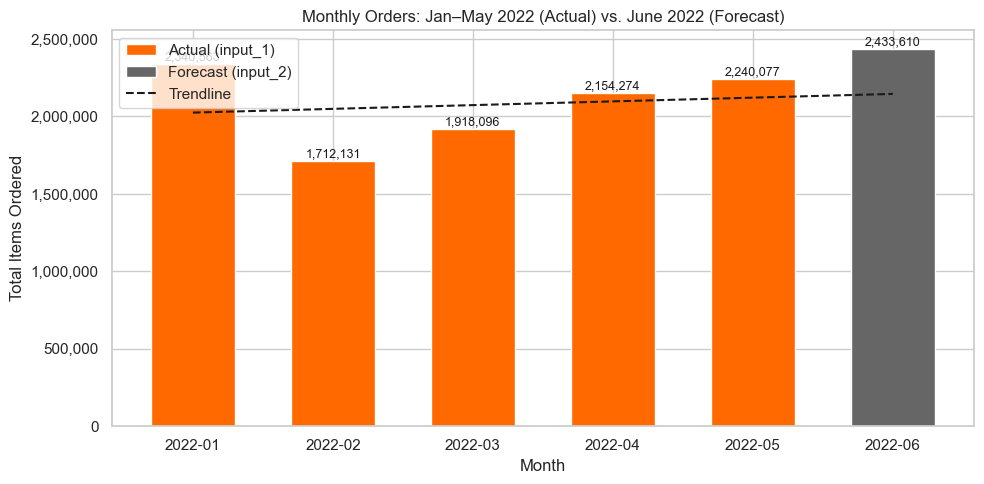

In [ ]:
# Plotting the monthly totals with a trendline (historical months + June forecast)
# Trendline through historical months only (exclude June forecast)
hist_only = monthly_orders[monthly_orders["month_str"] != "2022-06"].copy()
x = np.arange(len(hist_only))
slope, intercept, _, _, _ = linregress(x, hist_only["items"])
trendline_y = slope * np.arange(len(monthly_orders)) + intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#FF6900" if m != "2022-06" else "#666666" for m in monthly_orders["month_str"]]
bars = ax.bar(monthly_orders["month_str"], monthly_orders["items"], color=colors, width=0.6)

ax.plot(monthly_orders["month_str"], trendline_y, color="#1A1A1A", linewidth=1.5,
        linestyle="--", label="Trendline (historical)")

# Labels on bars
for bar, val in zip(bars, monthly_orders["items"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9, color="#1A1A1A")

ax.set_xlabel("Month")
ax.set_ylabel("Total Items Ordered")
ax.set_title("Monthly Orders: Jan–May 2022 (Actual) vs. June 2022 (Forecast)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FF6900", label="Actual (input_1)"),
    Patch(facecolor="#666666", label="Forecast (input_2)"),
    plt.Line2D([0], [0], color="#1A1A1A", linestyle="--", label="Trendline")
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

**Observations:**
- Overall trend is **upward** across Jan–May 2022, with a seasonal dip in February (shortest month, lowest demand).
- Consistent month-on-month recovery from March onwards: +12% (Mar), +12% (Apr), +4% (May).
- June forecast (2.43M) sits **above the trendline** and ~8.6% above May — consistent with the growth trajectory and likely reflects seasonal demand acceleration heading into summer.
- The trendline slope is modestly understated due to the February trough pulling it down; the Apr–May momentum is stronger than the line suggests.

### 3.2 Orders vs. Receivings by Calendar Week

In [142]:
# Orders by CW — derived inline from date_order
orders_by_cw = (
    hist.groupby(hist["date_order"].dt.isocalendar().week.astype(int))["items"]
    .sum().reset_index()
)
orders_by_cw.columns = ["CW", "ordered_items"]
orders_by_cw.head()

,CW,ordered_items
0,1,471070
1,2,532554
2,3,619536
3,4,583896
4,5,460164


In [143]:
# Receivings by CW — use existing CW column directly (based on date_wh_receive)
recv_by_cw = hist.groupby("CW")["items"].sum().reset_index()
recv_by_cw.columns = ["CW", "received_items"]
recv_by_cw.head()

,CW,received_items
0,1,450050
1,2,473232
2,3,596176
3,4,650974
4,5,455086


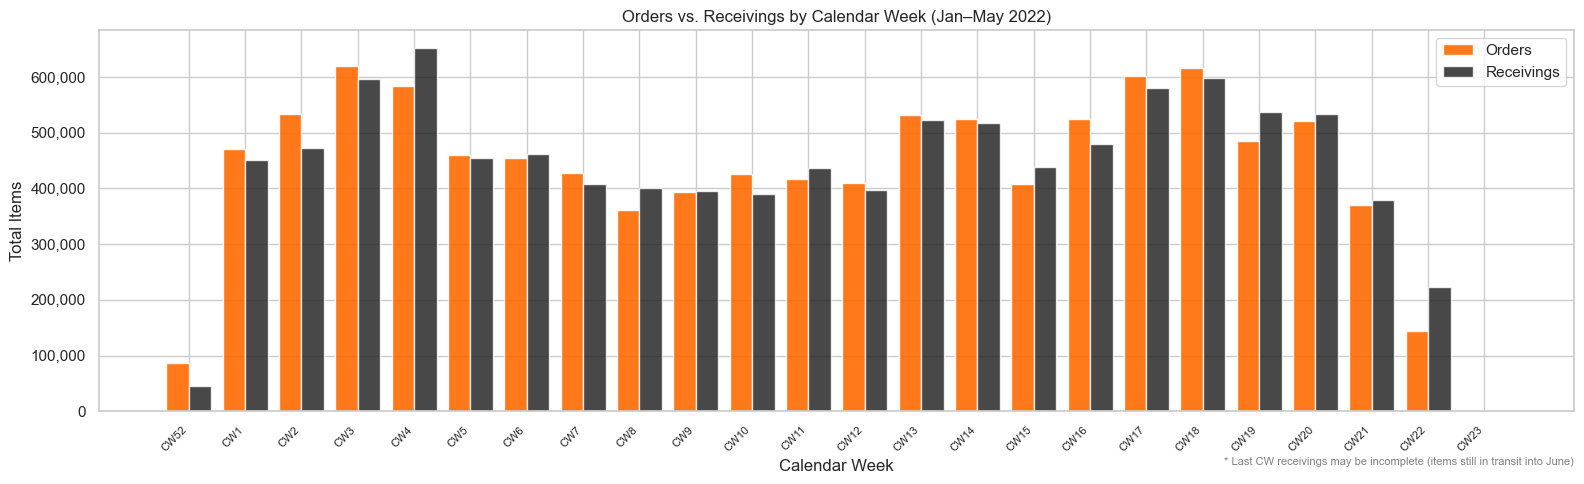

In [144]:
#Plotting orders vs. receivings by CW — merge on CW and sort by CW (with CW 52 first)
# Merge and sort — CW 52 covers Jan 1-2, sort to front
cw_df = orders_by_cw.merge(recv_by_cw, on="CW", how="outer").fillna(0)
cw_df = pd.concat([
    cw_df[cw_df["CW"] == 52],
    cw_df[cw_df["CW"] != 52].sort_values("CW")
]).reset_index(drop=True)

# Plot
x = np.arange(len(cw_df))
width = 0.4

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x - width/2, cw_df["ordered_items"], width, label="Orders", color="#FF6900", alpha=0.9)
ax.bar(x + width/2, cw_df["received_items"], width, label="Receivings", color="#1A1A1A", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"CW{int(cw)}" for cw in cw_df["CW"]], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Calendar Week")
ax.set_ylabel("Total Items")
ax.set_title("Orders vs. Receivings by Calendar Week (Jan–May 2022)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.legend()

ax.annotate("* Last CW receivings may be incomplete (items still in transit into June)",
            xy=(1, 0), xycoords="axes fraction",
            ha="right", va="bottom", fontsize=8, color="grey",
            xytext=(0, -40), textcoords="offset points")

plt.tight_layout()
plt.show()

**Observations:**
- Orders and receivings track closely for most weeks — confirming the lag is short and concentrated within the same or next week.
- **CW3–CW4 spike:** likely a post-Christmas/January sales effect; both orders and receivings peak here.
- **CW7–CW12 dip:** aligns with the February trough seen in the monthly chart — seasonal low demand.
- **CW13+ recovery:** steady growth from April onwards, consistent with the monthly upward trend.
- **CW22–23 divergence:** receivings drop off relative to orders — expected, as late May orders are still in transit into June (incomplete tail). This will be addressed in the May spillover calculation.

### 3.3 Orders vs. Receivings by Day of Week

### 3.4 Outliers in Historical Receiving Data

### 3.5 Lag Distribution Analysis

In [128]:
### Lag distribution stats
hist["lag"] = (hist["date_wh_receive"] - hist["date_order"]).dt.days
print("=== input_1: Lag Distribution (days) ===")
print(hist["lag"].describe())
print(f"\nPercentiles:")
for p in [90, 95, 99, 100]:
    print(f"  {p}th: {np.percentile(hist['lag'], p):.0f} days")

=== input_1: Lag Distribution (days) ===
count   1,763.0
mean        5.9
std         4.1
min         0.0
25%         2.0
50%         6.0
75%         9.0
max        26.0
Name: lag, dtype: float64

Percentiles:
  90th: 11 days
  95th: 12 days
  99th: 16 days
  100th: 26 days


**Observations**:
- 50% of all item arrivals happen within 6 days of order.
- 90% of all item arrivals happen within 11 days.
- Single longest observed lag is 26 days.
- The gap between the 99th (16 days) and 100th (26 days) is large — 10 days for just 1% of items. That's a strong signal that the tail beyond 16 days is rare outlier behaviour, not a meaningful pattern worth modelling.
- Note: these percentiles are **row-weighted** — see the item-weighted view in the visualisation below.

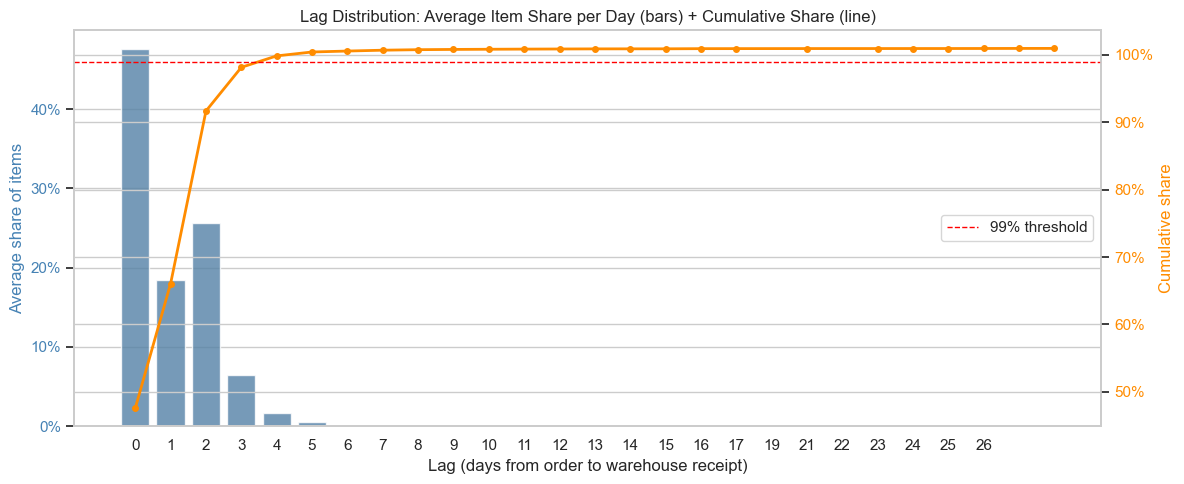

In [129]:
### Lag distribution visualisation (item-weighted)
lag_shares = (
    hist.groupby(["date_order", "lag"])["items"].sum()
    .div(hist.groupby("date_order")["items"].sum(), level="date_order")
    .groupby("lag").mean()
    .reset_index()
    .rename(columns={"items": "avg_share"})
)
lag_shares["cumulative_share"] = lag_shares["avg_share"].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(data=lag_shares, x="lag", y="avg_share", ax=ax1, color="steelblue", alpha=0.8)
ax1.set_xlabel("Lag (days from order to warehouse receipt)")
ax1.set_ylabel("Average share of items", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

ax2 = ax1.twinx()
ax2.plot(lag_shares["lag"], lag_shares["cumulative_share"], color="darkorange", linewidth=2, marker="o", markersize=4)
ax2.axhline(0.99, color="red", linestyle="--", linewidth=1, label="99% threshold")
ax2.set_ylabel("Cumulative share", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend(loc="center right")

plt.title("Lag Distribution: Average Item Share per Day (bars) + Cumulative Share (line)")
plt.tight_layout()
plt.show()

### 3.6 Lag Distribution by Day of Week

### 3.7 Lag Distribution by Calendar Week

### 3.8 Forecasted Items by Day of Week

### 3.9 Forecasted Items by Week

### 3.10 May Spillover Quantification